In [85]:
import sys
sys.path.append('/home/pulpo/Documents/quantitative-trading')
from src.quanttrading.analysis import calculate_stats, detect_outliers, get_percentiles
from src.quanttrading.data import prepare_data
import matplotlib.pyplot as plt
import pandas as pd

In [86]:
# DOWNLOAD DATA
df_eurusd = prepare_data('EURUSD=x', '1y', '4h')

df_eurusd.tail()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume,Return
Datetime,,,,,,
2026-04-29 23:00:00+00:00,1.166997,1.169317,1.166589,1.168224,0,-0.093360
2026-04-30 03:00:00+00:00,1.167270,1.167406,1.165909,1.167133,0,0.023341
2026-04-30 07:00:00+00:00,1.171646,1.171646,1.167406,1.167406,0,0.374927
2026-04-30 11:00:00+00:00,1.173434,1.173709,1.168770,1.172058,0,0.152557
2026-04-30 15:00:00+00:00,1.173296,1.173847,1.172745,1.173158,0,-0.011734


In [87]:
# SHOW SOME STATISTICS
stats = calculate_stats(df_eurusd['Return'])
for key, value in stats.items():
    print(f'{key}: {value: .3f}')

# PERCENTILES  
print('\nPERCENTILES:')
percentiles = get_percentiles(df_eurusd['Return'])
for key, value in percentiles.items():
    print(f'{key}: {value: .3f}')

# SHOW OUTLIERS
print('\nOUTLIERS')
outliers = detect_outliers(df_eurusd['Return'], thereshold=3)

print(f'Total de velas(4h):         {len(df_eurusd)}')
print(f'Total de dias con outliers: {outliers.sum()}')
print(f'Porcentaje:                {outliers.sum() / len(df_eurusd) * 100: .3f}%')

outlier_candles = df_eurusd[outliers][['Return']].copy()
outlier_candles['Distance from mean (STD)'] = ((df_eurusd['Return'] - stats['mean']).abs() / stats['std'])[outliers]
outlier_candles

mean:  0.002
std:  0.173
skew:  0.005
kurt:  5.842

PERCENTILES:
p05: -0.268
p25: -0.081
p75:  0.092
p95:  0.278

OUTLIERS
Total de velas(4h):         1556
Total de dias con outliers: 25
Porcentaje:                 1.607%


Price,Return,Distance from mean (STD)
Datetime,,
2025-05-02 15:00:00+00:00,-0.610382,3.541097
2025-05-12 07:00:00+00:00,-1.219374,7.061081
2025-05-19 07:00:00+00:00,0.631844,3.638987
2025-05-29 11:00:00+00:00,0.567661,3.268004
2025-06-12 07:00:00+00:00,0.626234,3.606557
2025-06-23 11:00:00+00:00,0.588240,3.386954
2025-07-15 11:00:00+00:00,-0.557885,3.237664
2025-07-28 07:00:00+00:00,-0.536509,3.114115
2025-07-29 03:00:00+00:00,-0.530809,3.081166


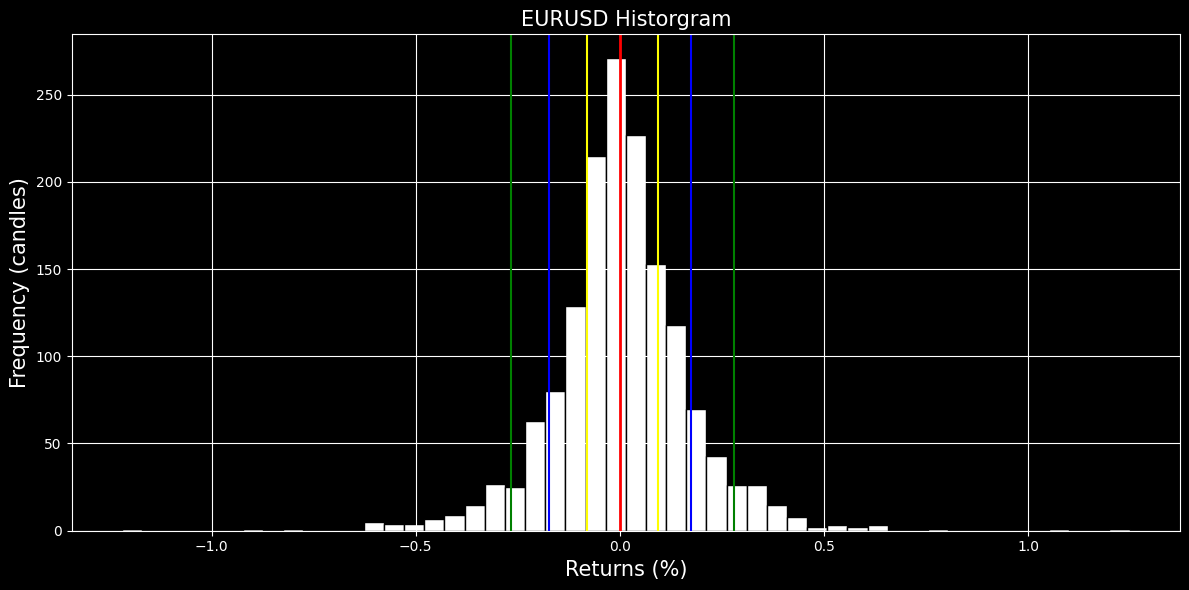

In [88]:
# HISTOGRAM
plt.figure(figsize=(12, 6))
plt.style.use('dark_background')
plt.hist(df_eurusd['Return'], bins=50, color='white', edgecolor='black')

plt.axvline(0, color='red', linestyle='-', linewidth=2)
plt.axvline(stats['std'], color='blue')
plt.axvline(-stats['std'], color='blue')

plt.axvline(percentiles['p05'], color='green')
plt.axvline(percentiles['p25'], color='yellow')
plt.axvline(percentiles['p75'], color='yellow')
plt.axvline(percentiles['p95'], color='green')

plt.title('EURUSD Historgram', fontsize=15)
plt.ylabel('Frequency (candles)', fontsize=15)
plt.xlabel('Returns (%)', fontsize=15)

plt.tight_layout()
plt.grid(True)
plt.show()

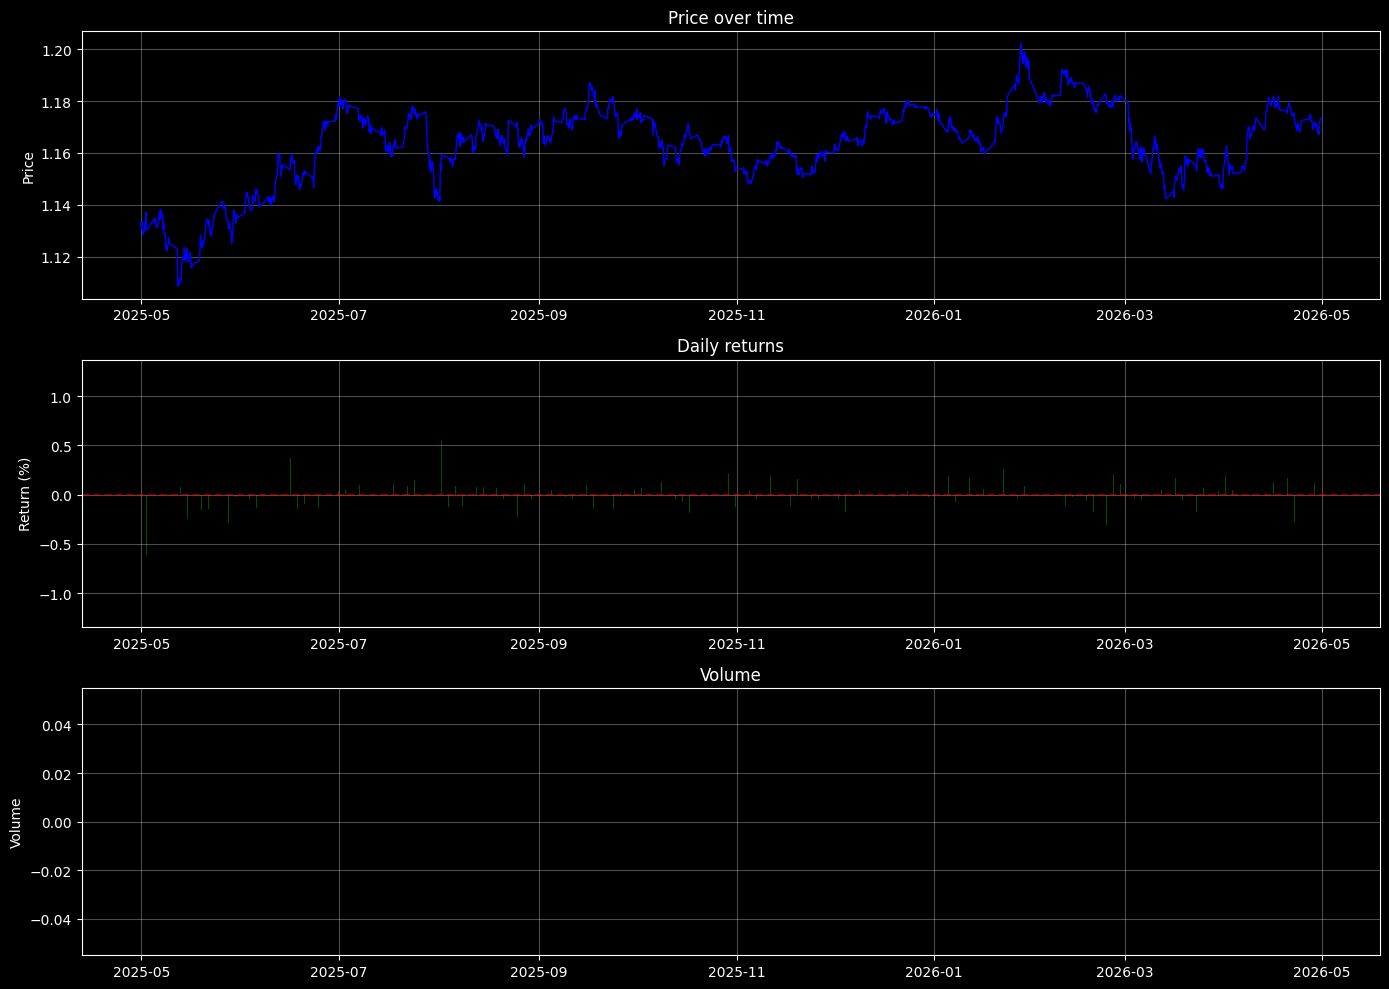

In [89]:
# TIME SERIES 
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

#Price
axes[0].plot(df_eurusd.index, df_eurusd['Close'], color='blue', linewidth=1)
axes[0].set_title('Price over time')
axes[0].grid(True, alpha=0.3)
axes[0].set_ylabel('Price')

# RETURNS
axes[1].bar(df_eurusd.index, df_eurusd['Return'], color='green', alpha=0.6, width=0.02)
axes[1].axhline(y=0, color='red', linestyle='--', alpha=0.5)
axes[1].set_title('Daily returns')
axes[1].set_ylabel('Return (%)')
axes[1].grid(True, alpha=0.3)

# VOLUME
axes[2].bar(df_eurusd.index, df_eurusd['Volume'], color='orange', alpha=0.6, width=0.02)
axes[2].grid(True, alpha=0.3)
axes[2].set_title('Volume')
axes[2].set_ylabel('Volume')

plt.tight_layout()
plt.show()

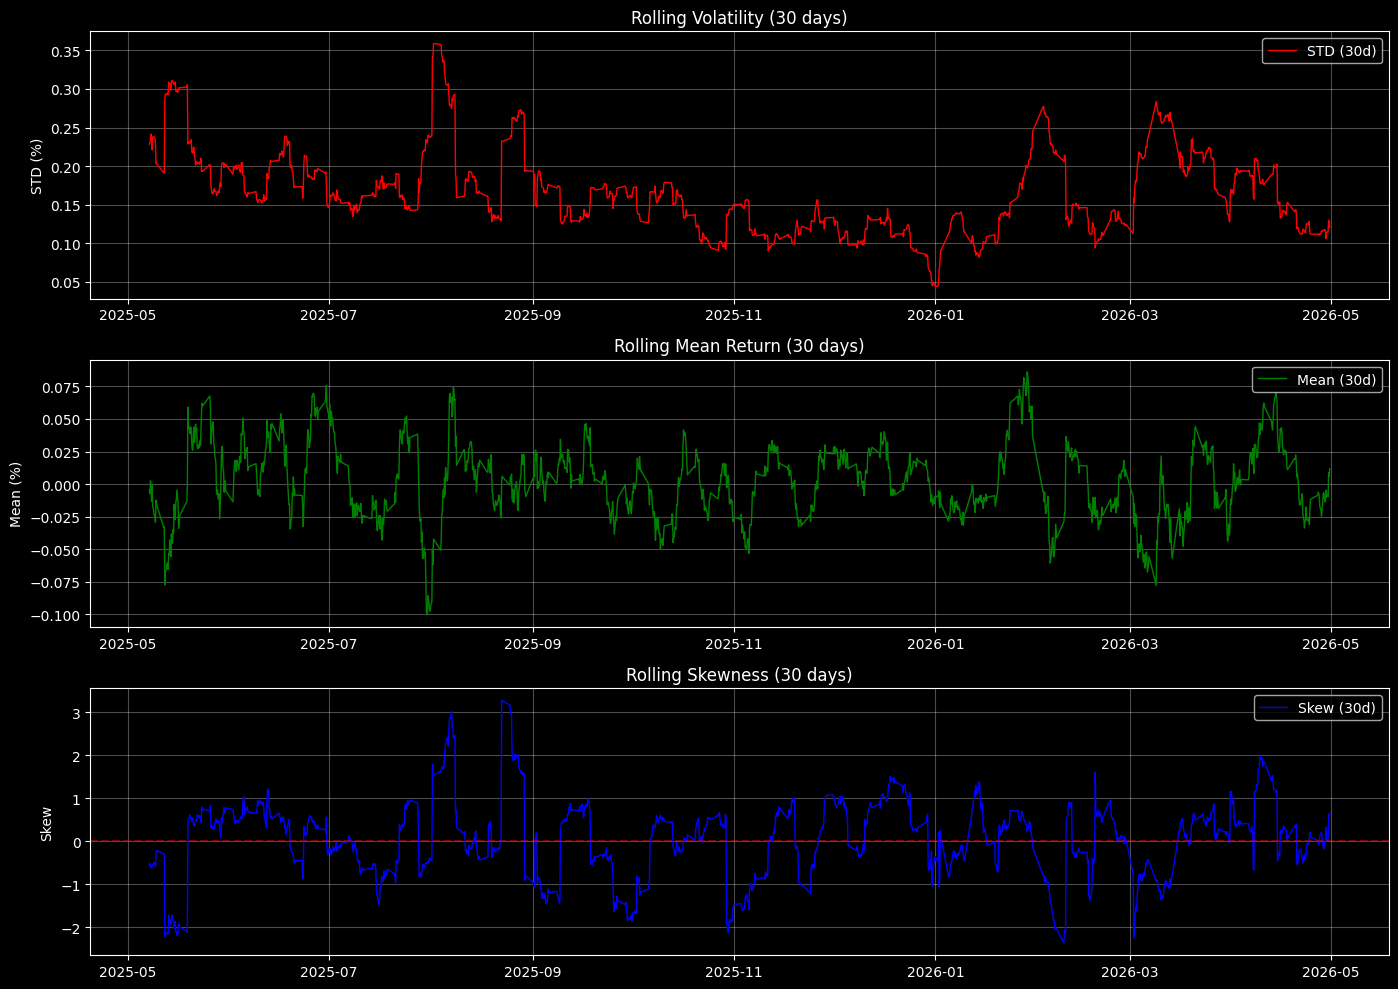

In [93]:
# ROLLING STATISTICS
df_eurusd['std_30'] = df_eurusd['Return'].rolling(30).std()
df_eurusd['mean_30'] = df_eurusd['Return'].rolling(30).mean()
df_eurusd['skew_30'] = df_eurusd['Return'].rolling(30).skew()

fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# STD
axes[0].plot(df_eurusd.index, df_eurusd['std_30'], color='red', linewidth=1, label='STD (30d)')
axes[0].set_title('Rolling Volatility (30 days)')
axes[0].set_ylabel('STD (%)')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# MEAN
axes[1].plot(df_eurusd.index, df_eurusd['mean_30'], color='green', linewidth=1, label='Mean (30d)')
axes[1].set_title('Rolling Mean Return (30 days)')
axes[1].set_ylabel('Mean (%)')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

# SKEW
axes[2].plot(df_eurusd.index, df_eurusd['skew_30'], color='blue', linewidth=1, label='Skew (30d)')
axes[2].axhline(y=0, color='red', linestyle='--', alpha=0.5)
axes[2].set_title('Rolling Skewness (30 days)')
axes[2].grid(True, alpha=0.3)
axes[2].set_ylabel('Skew')
axes[2].legend()

plt.tight_layout()
plt.show()